In [5]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines  # needed for custom legend markers
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline

In [22]:
print(len(raw), len(df_clean), len(df_markgeodata))

28471 28470 27981


In [6]:


gpd.options.io_engine = "pyogrio"  # faster engine

rf = r"C:/Projects/GeoChem-DataLab/raw_data/markgeokemi_regional.gpkg"
raw = gpd.read_file(
    rf,
    layer="moran_0063mm_hno3_icpms",  # moran_0063mm_hno3_icpms
    use_arrow=True
)

# Drop rows with missing ID/coordinates & ensure SWEREF system
df_clean = raw.dropna(
    subset=["unikt_id", "ns", "ew", "geometry"]
).set_crs("EPSG:3006", allow_override=True)

# save cleaned data to GeoPackage
df_clean.to_file(
    "C:/Projects/GeoChem-DataLab/cleaned_data/df_clean.gpkg",
    driver="GPKG",
    use_arrow=True
)

# 4.1 Filter: keep only rows with valid, positive As/Fe/Ca/Al/U
# (0 = "not analyzed" per SGU product description; excluded by > 0)
df_markgeodata = df_clean[
    (df_clean["as_ppm"].notna()) & (df_clean["as_ppm"] > 0) &   # As: valid, positive only
    (df_clean["fe_ppm"].notna()) & (df_clean["fe_ppm"] > 0) &   # Fe: valid, positive only
    (df_clean["ca_ppm"].notna()) & (df_clean["ca_ppm"] > 0) &   # Ca: valid, positive only
    (df_clean["al_ppm"].notna()) & (df_clean["al_ppm"] > 0) &   # Al: valid, positive only
    (df_clean["u_ppm"].notna())  & (df_clean["u_ppm"] > 0)      # U: valid, positive only
][[
    "unikt_id", "ns", "ew",
    "as_ppm", "fe_ppm", "ca_ppm", "al_ppm", "u_ppm",
    "geometry"]].copy()  # keep only needed columns; independent copy

print(f"Analysis-ready sample points: {len(df_markgeodata)}")  # expect ~28,470

# 4.2 Relative screening: 75th and 95th percentile thresholds
as_p75 = df_markgeodata["as_ppm"].quantile(0.75)
as_p95 = df_markgeodata["as_ppm"].quantile(0.95)
print(f"As: 75th = {as_p75:.2f} ppm, 95th = {as_p95:.2f} ppm")

u_p75 = df_markgeodata["u_ppm"].quantile(0.75)
u_p95 = df_markgeodata["u_ppm"].quantile(0.95)
print(f"U: 75th = {u_p75:.2f} ppm, 95th = {u_p95:.2f} ppm")

C:\Users\Admin\anaconda3\Lib\site-packages\pyogrio\geopandas.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["geometry"] = shapely.from_wkb(wkb_values, on_invalid=on_invalid)


Analysis-ready sample points: 27981
As: 75th = 3.90 ppm, 95th = 13.00 ppm
U: 75th = 2.40 ppm, 95th = 4.60 ppm


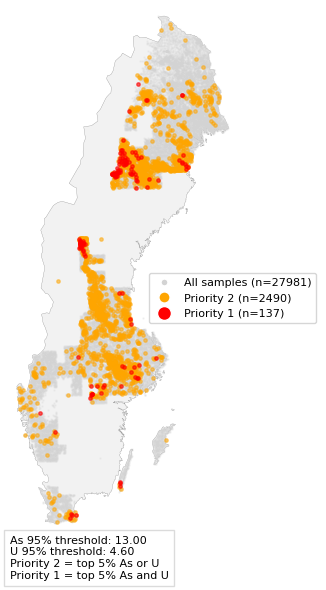

priority
Background    25354
Priority 2     2490
Priority 1      137
Name: count, dtype: int64


In [8]:
# COMBINED — As + U Priority
#---------------------
world = gpd.read_file(
    r"C:/Projects/GeoChem-DataLab/raw_data/ne_110m_admin_0_countries/ne_10m_admin_0_countries.shp"
)#spf of country boundary polygon: ne_10m_admin_0_countries.shp
sweden = world[world["ADMIN"] == "Sweden"].to_crs("EPSG:3006") #Sweden's boundary polygon
# Hotspot flags (top 5% per element) — uses as_p95/u_p95 from shared setup
df_markgeodata["as_hotspot"] = df_markgeodata["as_ppm"] > as_p95
df_markgeodata["u_hotspot"] = df_markgeodata["u_ppm"] > u_p95
df_markgeodata["priority"] = np.select(
    [
        df_markgeodata["as_hotspot"] & df_markgeodata["u_hotspot"],  # both hot
        df_markgeodata["as_hotspot"] | df_markgeodata["u_hotspot"]   # either hot
    ],
    ["Priority 1", "Priority 2"],
    default="Background"
)
priority1 = df_markgeodata[df_markgeodata["priority"] == "Priority 1"] # both As and U in top 5%
priority2 = df_markgeodata[df_markgeodata["priority"] == "Priority 2"] # either As or U in top 5%
fig, ax = plt.subplots(figsize=(4, 6))
sweden.plot(ax=ax, edgecolor="grey", facecolor="#f2f2f2", linewidth=0.2)#Sweden outline
df_markgeodata.plot(ax=ax, color="lightgrey", markersize=0.5, alpha=0.25)# draw data as dots on Sweden base map
priority2.plot(ax=ax, color="orange", markersize=6, alpha=0.5) #plot priority 2, orange
priority1.plot(ax=ax, color="red", markersize=6, alpha=0.6) #plot priority 1, red
minx, miny, maxx, maxy = sweden.total_bounds #get sweden bbox. in meters, since it is in EPSG:3006
pad = 20000  # 20 km margin
ax.set_xlim(minx - pad, maxx + pad) # crop x-axis to Sweden + padding
ax.set_ylim(miny - pad, maxy + pad) # crop y-axis to Sweden + padding
legend_elements = [                                            # build custom legend entries
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"All samples (n={len(df_markgeodata)})",
                  markerfacecolor="lightgrey", markersize=5),
    mlines.Line2D([0], [0], marker="o", color="w",              # hide x/y axis lines/ticks
                  label=f"Priority 2 (n={len(priority2)})",
                  markerfacecolor="orange", markersize=8),
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"Priority 1 (n={len(priority1)})",
                  markerfacecolor="red", markersize=10)
]
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0.6, 0.5),# place legend outside plot
          borderaxespad=0.3, fontsize=8, frameon=True)
ax.set_axis_off()
ax.text(
    0.0, -0.01,
    f"As 95% threshold: {as_p95:.2f}\n"
    f"U 95% threshold: {u_p95:.2f}\n"
    "Priority 2 = top 5% As or U\n"
    "Priority 1 = top 5% As and U",
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="lightgrey")
)
plt.tight_layout()
fig.savefig(
    r"C:/Projects/GeoChem-DataLab/results/sweden_as_u_priority_map.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print(df_markgeodata["priority"].value_counts())  # check against report: Priority 1 = 145, Priority 2 = 2,564

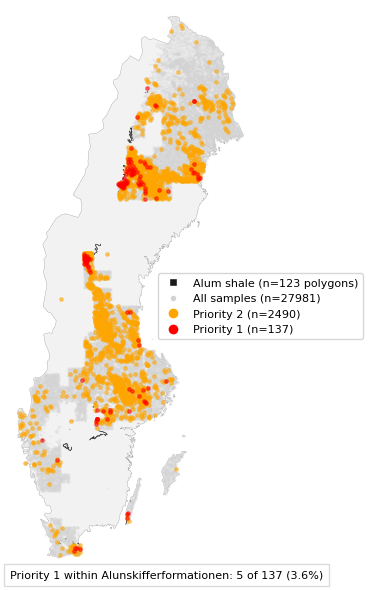

In [11]:
# Alum Shale + Priority 1/2
#---------------------
world = gpd.read_file(
    r"C:/Projects/GeoChem-DataLab/raw_data/ne_110m_admin_0_countries/ne_10m_admin_0_countries.shp"
)
sweden = world[world["ADMIN"] == "Sweden"].to_crs("EPSG:3006")

bedrock_path = r"C:/Projects/GeoChem-DataLab/raw_data/berggrund50k-250k/berggrund50k_250k.gpkg"
bedrock = gpd.read_file(bedrock_path, layer="geologisk_enhet_yta", use_arrow=True)
alum_shale = bedrock[
    bedrock["lito_n_tx"].astype(str).str.contains("Alunskifferformationen", case=False, na=False)
].to_crs("EPSG:3006")

fig, ax = plt.subplots(figsize=(4, 6))
sweden.plot(ax=ax, edgecolor="grey", facecolor="#f2f2f2", linewidth=0.2)
alum_shale.plot(ax=ax, color="#1A1A1A", alpha=0.6, edgecolor="black", linewidth=0.4)
df_markgeodata.plot(ax=ax, color="lightgrey", markersize=0.5, alpha=0.25)
priority2.plot(ax=ax, color="orange", markersize=6, alpha=0.5)
priority1.plot(ax=ax, color="red", markersize=6, alpha=0.5)

minx, miny, maxx, maxy = sweden.total_bounds
pad = 20000
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

legend_elements = [
    mlines.Line2D([0], [0], marker="s", color="w",
                  label=f"Alum shale (n={len(alum_shale)} polygons)",
                  markerfacecolor="#1A1A1A", markersize=6),
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"All samples (n={len(df_markgeodata)})",
                  markerfacecolor="lightgrey", markersize=5),
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"Priority 2 (n={len(priority2)})",
                  markerfacecolor="orange", markersize=8),
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"Priority 1 (n={len(priority1)})",
                  markerfacecolor="red", markersize=8)
]
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0.6, 0.53),
          borderaxespad=0.3, fontsize=8, frameon=True)
ax.set_axis_off()

priority1_on_shale = gpd.sjoin(priority1, alum_shale, how="inner", predicate="within")
pct_overlap = len(priority1_on_shale) / len(priority1) * 100 if len(priority1) > 0 else 0

ax.text(
    0.0, -0.01,
    f"Priority 1 within Alunskifferformationen: {len(priority1_on_shale)} of {len(priority1)} ({pct_overlap:.1f}%)",
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="lightgrey")
)
plt.tight_layout()
fig.savefig(
    r"C:/Projects/GeoChem-DataLab/results/alum_shale_priority_overlay.png",
    dpi=300, bbox_inches="tight"
)
plt.show()